In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('../data/processed/df_clean.csv')

# Drop family_size as decided in EDA
df = df.drop(columns=['family_size'])

with open('../data/processed/feature_cols.json') as f:
    feature_cols = json.load(f)

feature_cols = [c for c in feature_cols if c != 'family_size']

print(f"Shape : {df.shape}")
print(f"Features : {len(feature_cols)}")

Shape : (404800, 26)
Features : 24


In [2]:
# financial ratio features
# 1. Debt to Income Ratio
# How much of monthly salary goes to existing EMI
df['debt_to_income_ratio'] = df['current_emi_amount'] / (df['monthly_salary'] + 1)

# 2. Total monthly expenses
df['total_expenses'] = (
    df['monthly_rent'] +
    df['school_fees'] +
    df['college_fees'] +
    df['travel_expenses'] +
    df['groceries_utilities'] +
    df['other_monthly_expenses'] +
    df['current_emi_amount']
)

# 3. Expense to Income Ratio
# What fraction of salary is spent on expenses
df['expense_to_income_ratio'] = df['total_expenses'] / (df['monthly_salary'] + 1)

# 4. Disposable Income
# What is left after all expenses
df['disposable_income'] = df['monthly_salary'] - df['total_expenses']

# 5. Affordability Ratio
# Can the person afford the requested EMI
df['affordability_ratio'] = df['disposable_income'] / (df['requested_amount'] + 1)

print("Financial ratio features created:")
print(df[['debt_to_income_ratio', 'expense_to_income_ratio',
          'disposable_income', 'affordability_ratio', 'total_expenses']].describe())

Financial ratio features created:
       debt_to_income_ratio  expense_to_income_ratio  disposable_income  \
count         404800.000000            404800.000000      404800.000000   
mean               0.083591                 0.867160       14831.331744   
std                0.142251                 0.636453       37581.517747   
min                0.000000                 0.011144     -161883.000000   
25%                0.000000                 0.606754         400.000000   
50%                0.000000                 0.779105       10600.000000   
75%                0.174420                 0.991181       22400.000000   
max                7.702943                31.285799      485540.000000   

       affordability_ratio  total_expenses  
count        404800.000000   404800.000000  
mean              0.106328    44639.560099  
std               0.471324    23072.348857  
min              -6.946905     3600.000000  
25%               0.001036    27900.000000  
50%               0.

In [3]:

# 6. Savings to Income Ratio
df['savings_to_income_ratio'] = df['bank_balance'] / (df['monthly_salary'] + 1)

# 7. Emergency Fund Coverage
# How many months of expenses covered by emergency fund
df['emergency_fund_months'] = df['emergency_fund'] / (df['total_expenses'] + 1)

# 8. Credit Score Band
# Categorize credit score into risk bands
df['credit_score_band'] = pd.cut(
    df['credit_score'],
    bins=[0, 579, 669, 739, 799, 850],
    labels=[0, 1, 2, 3, 4]  # Poor, Fair, Good, Very Good, Excellent
).astype(float)

# 9. Loan to Income Ratio
# Requested amount vs annual salary
df['loan_to_income_ratio'] = df['requested_amount'] / (df['monthly_salary'] * 12 + 1)

print("Credit & savings features created:")
print(df[['savings_to_income_ratio', 'emergency_fund_months',
          'credit_score_band', 'loan_to_income_ratio']].describe())

Credit & savings features created:
       savings_to_income_ratio  emergency_fund_months  credit_score_band  \
count            404800.000000          404800.000000      404800.000000   
mean                  4.448208               2.335039           1.997979   
std                   3.958771               1.728584           0.969953   
min                   0.020562               0.033481           0.000000   
25%                   2.344933               1.044803           1.000000   
50%                   4.235680               1.928896           2.000000   
75%                   6.143559               3.175829           3.000000   
max                 218.419512              16.609913           4.000000   

       loan_to_income_ratio  
count         404800.000000  
mean               0.725624  
std                0.960179  
min                0.001893  
25%                0.182455  
50%                0.398803  
75%                0.902616  
max               24.546005  


In [4]:
# 10. Composite Risk Score (0 = low risk, higher = more risk)
# Combines multiple risk signals into one score

df['risk_score'] = (
    df['debt_to_income_ratio'] * 0.30 +
    df['expense_to_income_ratio'] * 0.25 +
    df['loan_to_income_ratio'] * 0.25 +
    (1 - df['credit_score'] / 850) * 0.20
)

print("Risk score created:")
print(df['risk_score'].describe())
print(f"\nTop 5 highest risk scores:")
print(df[['monthly_salary', 'credit_score', 'risk_score',
          'emi_eligibility']].nlargest(5, 'risk_score'))

Risk score created:
count    404800.000000
mean          0.458478
std           0.344697
min           0.011976
25%           0.282901
50%           0.382247
75%           0.527380
max          11.108980
Name: risk_score, dtype: float64

Top 5 highest risk scores:
        monthly_salary  credit_score  risk_score  emi_eligibility
276126          5089.0         729.0   11.108980                0
61009           5958.0         793.0   10.990410                0
301700          5062.0         656.0   10.721234                0
366594          5568.0         649.0   10.365114                0
326886          5688.0         617.0    9.906884                0


In [5]:
# 11. Salary x Credit Score interaction
df['salary_credit_interaction'] = df['monthly_salary'] * df['credit_score'] / 100000

# 12. Disposable income per dependent
df['income_per_dependent'] = df['disposable_income'] / (df['dependents'] + 1)

# 13. Rent burden (rent as % of salary)
df['rent_burden'] = df['monthly_rent'] / (df['monthly_salary'] + 1)

# 14. EMI burden (existing EMI as % of salary)
df['emi_burden'] = df['current_emi_amount'] / (df['monthly_salary'] + 1)

print("Interaction features created:")
print(df[['salary_credit_interaction', 'income_per_dependent',
          'rent_burden', 'emi_burden']].describe())

Interaction features created:
       salary_credit_interaction  income_per_dependent    rent_burden  \
count               404800.00000         404800.000000  404800.000000   
mean                   419.10927           6609.089560       0.107725   
std                    312.08874          18010.896232       0.179543   
min                     25.34913        -156054.000000       0.000000   
25%                    243.26400            125.000000       0.000000   
50%                    356.63600           3666.666667       0.000000   
75%                    513.39000           8666.666667       0.227023   
max                   4206.74350         482225.000000      10.579345   

          emi_burden  
count  404800.000000  
mean        0.083591  
std         0.142251  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.174420  
max         7.702943  


In [6]:
# All new engineered features
new_features = [
    'debt_to_income_ratio',
    'total_expenses',
    'expense_to_income_ratio',
    'disposable_income',
    'affordability_ratio',
    'savings_to_income_ratio',
    'emergency_fund_months',
    'credit_score_band',
    'loan_to_income_ratio',
    'risk_score',
    'salary_credit_interaction',
    'income_per_dependent',
    'rent_burden',
    'emi_burden'
]

# Update feature cols
feature_cols_engineered = feature_cols + new_features

print(f"Original features  : {len(feature_cols)}")
print(f"New features added : {len(new_features)}")
print(f"Total features now : {len(feature_cols_engineered)}")

Original features  : 24
New features added : 14
Total features now : 38


In [7]:
print("Checking for inf/NaN in engineered features:")
print("-" * 45)
for col in new_features:
    inf_count = np.isinf(df[col]).sum()
    nan_count = df[col].isnull().sum()
    if inf_count > 0 or nan_count > 0:
        print(f"  ⚠️  {col:<35} inf: {inf_count}  nan: {nan_count}")
    else:
        print(f"  ✅  {col}")

Checking for inf/NaN in engineered features:
---------------------------------------------
  ✅  debt_to_income_ratio
  ✅  total_expenses
  ✅  expense_to_income_ratio
  ✅  disposable_income
  ✅  affordability_ratio
  ✅  savings_to_income_ratio
  ✅  emergency_fund_months
  ✅  credit_score_band
  ✅  loan_to_income_ratio
  ✅  risk_score
  ✅  salary_credit_interaction
  ✅  income_per_dependent
  ✅  rent_burden
  ✅  emi_burden


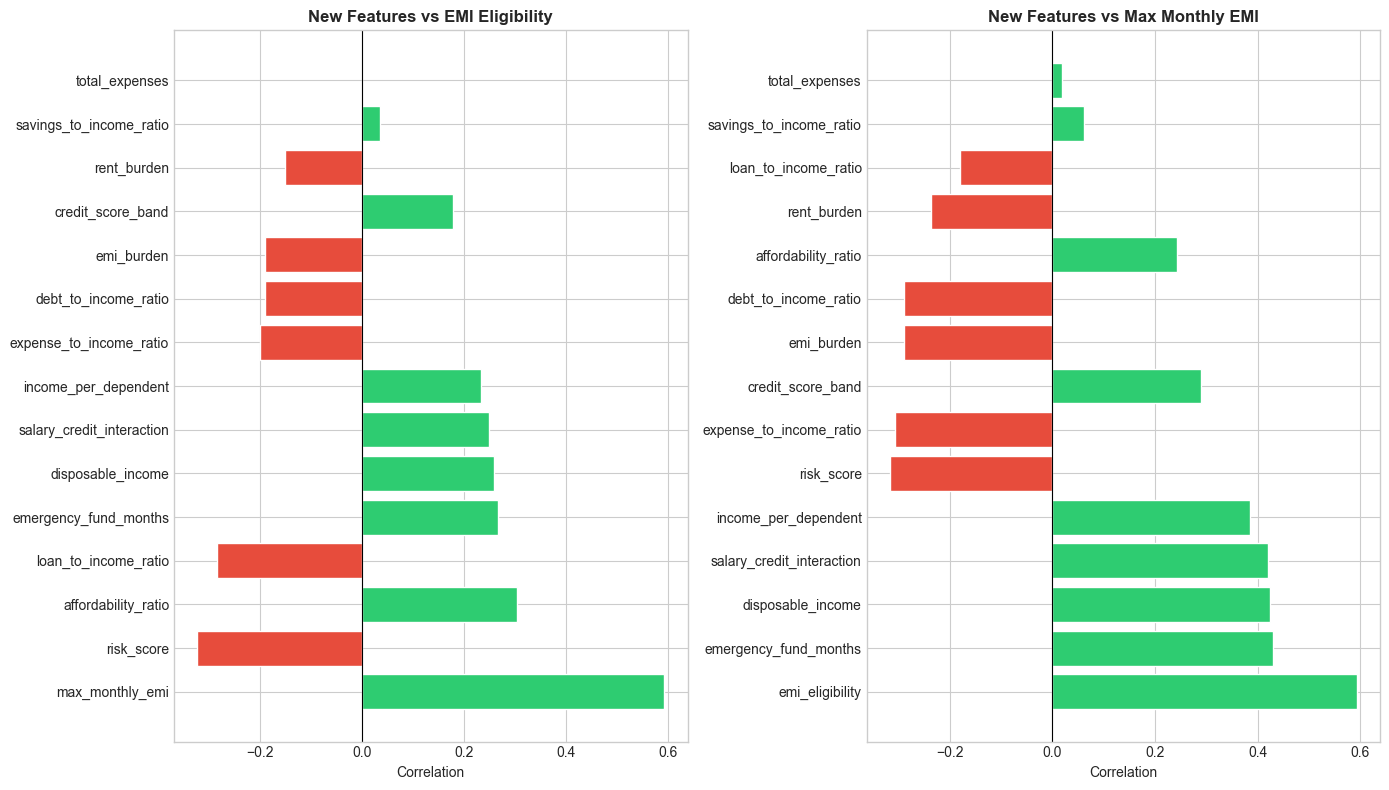

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Correlation of NEW features with both targets
new_feat_df = df[new_features + ['emi_eligibility', 'max_monthly_emi']]
corr = new_feat_df.corr()

# With emi_eligibility
corr_class = corr['emi_eligibility'].drop('emi_eligibility').sort_values(key=abs, ascending=False)
colors_c = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_class.values]
axes[0].barh(corr_class.index, corr_class.values, color=colors_c, edgecolor='white')
axes[0].set_title('New Features vs EMI Eligibility', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlation')
axes[0].axvline(0, color='black', linewidth=0.8)

# With max_monthly_emi
corr_reg = corr['max_monthly_emi'].drop('max_monthly_emi').sort_values(key=abs, ascending=False)
colors_r = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_reg.values]
axes[1].barh(corr_reg.index, corr_reg.values, color=colors_r, edgecolor='white')
axes[1].set_title('New Features vs Max Monthly EMI', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlation')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../data/processed/engineered_feature_correlations.png', dpi=120)
plt.show()

In [9]:
# Engineer datset save
import os
import json

os.makedirs('../data/processed', exist_ok=True)

# Save full engineered dataset
df.to_csv('../data/processed/df_engineered.csv', index=False)

# Save updated feature list
with open('../data/processed/feature_cols_engineered.json', 'w') as f:
    json.dump(feature_cols_engineered, f)

print(f"Engineered dataset saved")
print(f"Shape : {df.shape}")
print(f"Total features : {len(feature_cols_engineered)}")
print(f"\nFiles saved:")
for f in os.listdir('../data/processed/'):
    print(f"  {f}")

Engineered dataset saved
Shape : (404800, 40)
Total features : 38

Files saved:
  age_by_eligibility.png
  avg_emi_by_scenario.png
  boxplots_by_eligibility.png
  correlation_heatmap.png
  creditscore_by_eligibility.png
  df_clean.csv
  df_engineered.csv
  eligibility_by_employment.png
  eligibility_by_scenario.png
  emi_by_education.png
  engineered_feature_correlations.png
  feature_cols.json
  feature_cols_engineered.json
  salary_by_eligibility.png
  scenario_distribution.png
  target_distribution.png
  top_feature_correlations.png
  X_test.csv
  X_train.csv
  X_val.csv
  yc_test.csv
  yc_train.csv
  yc_val.csv
  yr_test.csv
  yr_train.csv
  yr_val.csv


In [11]:
from sklearn.model_selection import train_test_split

TARGET_CLASS = 'emi_eligibility'
TARGET_REG   = 'max_monthly_emi'

X = df[feature_cols_engineered]
y_class = df[TARGET_CLASS]
y_reg   = df[TARGET_REG]

# 70% train / 15% val / 15% test
X_temp, X_test, yc_temp, yc_test, yr_temp, yr_test = train_test_split(
    X, y_class, y_reg,
    test_size=0.15,
    random_state=42,
    stratify=y_class
)

X_train, X_val, yc_train, yc_val, yr_train, yr_val = train_test_split(
    X_temp, yc_temp, yr_temp,
    test_size=0.176,
    random_state=42,
    stratify=yc_temp
)

# Save new splits
X_train.to_csv('../data/processed/X_train_eng.csv', index=False)
X_val.to_csv('../data/processed/X_val_eng.csv',     index=False)
X_test.to_csv('../data/processed/X_test_eng.csv',   index=False)

yc_train.to_csv('../data/processed/yc_train.csv', index=False)
yc_val.to_csv('../data/processed/yc_val.csv',     index=False)
yc_test.to_csv('../data/processed/yc_test.csv',   index=False)

yr_train.to_csv('../data/processed/yr_train.csv', index=False)
yr_val.to_csv('../data/processed/yr_val.csv',     index=False)
yr_test.to_csv('../data/processed/yr_test.csv',   index=False)

print(f"Train      : {len(X_train):,} rows")
print(f"Validation : {len(X_val):,} rows")
print(f"Test       : {len(X_test):,} rows")
print(f"Features   : {X_train.shape[1]}")


Train      : 283,521 rows
Validation : 60,559 rows
Test       : 60,720 rows
Features   : 38
